In [ ]:
import json
import os
from collections import Counter
from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple

import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input


@dataclass
class Config:
    data_dir: str = "drive/MyDrive/dataset_csv"
    model_dir: str = "artifacts"
    sequence_length: int = 50
    sequence_step: int = 10
    test_size: float = 0.2
    val_size: float = 0.1
    random_state: int = 42
    batch_size: int = 32
    epochs: int = 80
    learning_rate: float = 1e-3
    use_class_weights: bool = True
    features: Tuple[str, ...] = (
        "flex_thumb",
        "flex_index",
        "flex_middle",
        "flex_ring",
        "flex_little",
        "accX",
        "accY",
        "accZ",
        "gyroX",
        "gyroY",
        "gyroZ",
    )
    label_col: str = "label"
    timestamp_col: str = "timestamp"


CFG = Config()

COLUMN_ALIASES: Dict[str, Tuple[str, ...]] = {
    "timestamp": ("timestamp", "t_ms", "time", "ts"),
    "flex_thumb": ("flex_thumb", "flex1", "thumb"),
    "flex_index": ("flex_index", "flex2", "index"),
    "flex_middle": ("flex_middle", "flex3", "middle"),
    "flex_ring": ("flex_ring", "flex4", "ring"),
    "flex_little": ("flex_little", "flex5", "little", "pinky"),
    "accX": ("accX", "ax", "accx"),
    "accY": ("accY", "ay", "accy"),
    "accZ": ("accZ", "az", "accz"),
    "gyroX": ("gyroX", "gx", "gyrox"),
    "gyroY": ("gyroY", "gy", "gyroy"),
    "gyroZ": ("gyroZ", "gz", "gyroz"),
    "label": ("label", "gesture", "class", "word"),
}


def normalize_key(text: str) -> str:
    return "".join(ch for ch in str(text).lower() if ch.isalnum())


def ensure_dirs() -> None:
    os.makedirs(CFG.model_dir, exist_ok=True)


def seed_everything(seed: int) -> None:
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def find_matching_column(columns: Iterable[str], aliases: Iterable[str]) -> str | None:
    normalized = {normalize_key(col): col for col in columns}
    for alias in aliases:
        key = normalize_key(alias)
        if key in normalized:
            return normalized[key]
    return None


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map: Dict[str, str] = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        if canonical in df.columns:
            continue
        match = find_matching_column(df.columns, aliases)
        if match is not None and match not in rename_map:
            rename_map[match] = canonical
    if rename_map:
        df = df.rename(columns=rename_map)
    return df


def load_csv_files(data_dir: str) -> List[pd.DataFrame]:
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory '{data_dir}' was not found.")

    csv_files = sorted(
        os.path.join(data_dir, filename)
        for filename in os.listdir(data_dir)
        if filename.lower().endswith(".csv")
    )
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in '{data_dir}'.")

    dataframes: List[pd.DataFrame] = []
    for path in csv_files:
        df = pd.read_csv(path)
        df["__source_file"] = os.path.basename(path)
        df = standardize_columns(df)
        dataframes.append(df)
    return dataframes


def sort_by_timestamp_if_possible(df: pd.DataFrame) -> pd.DataFrame:
    if CFG.timestamp_col not in df.columns:
        return df

    ts_raw = df[CFG.timestamp_col]
    ts_numeric = pd.to_numeric(ts_raw, errors="coerce")
    if ts_numeric.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_numeric).sort_values("__ts_sort").drop(columns="__ts_sort")

    ts_datetime = pd.to_datetime(ts_raw, errors="coerce")
    if ts_datetime.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_datetime).sort_values("__ts_sort").drop(columns="__ts_sort")

    return df


def validate_and_clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    required_columns = set(CFG.features) | {CFG.label_col}
    missing = required_columns - set(df.columns)
    if missing:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"Missing columns in {source}: {sorted(missing)}")

    df = sort_by_timestamp_if_possible(df).copy()
    df[list(CFG.features)] = df[list(CFG.features)].apply(pd.to_numeric, errors="coerce")
    df[CFG.label_col] = df[CFG.label_col].astype(str).str.strip()
    df = df.replace([np.inf, -np.inf], np.nan)

    valid_mask = df[list(CFG.features)].notna().all(axis=1) & df[CFG.label_col].ne("") & df[CFG.label_col].notna()
    cleaned = df.loc[valid_mask].reset_index(drop=True)
    if cleaned.empty:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"After cleaning there are no valid rows left in {source}.")
    return cleaned


def split_contiguous_label_segments(df: pd.DataFrame) -> List[pd.DataFrame]:
    labels = df[CFG.label_col].astype(str)
    segment_ids = labels.ne(labels.shift(1)).cumsum()
    return [segment.reset_index(drop=True) for _, segment in df.groupby(segment_ids, sort=False)]


def create_sequences_from_segment(
    segment: pd.DataFrame,
    source_group: str,
    sequence_length: int,
    sequence_step: int,
) -> Tuple[List[np.ndarray], List[str], List[str]]:
    values = segment[list(CFG.features)].to_numpy(dtype=np.float32)
    label = segment[CFG.label_col].iloc[0]

    X_list: List[np.ndarray] = []
    y_list: List[str] = []
    g_list: List[str] = []

    if len(values) < sequence_length:
        return X_list, y_list, g_list

    for start in range(0, len(values) - sequence_length + 1, sequence_step):
        end = start + sequence_length
        X_list.append(values[start:end])
        y_list.append(label)
        g_list.append(source_group)

    return X_list, y_list, g_list


def build_dataset(dataframes: List[pd.DataFrame]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    X_all: List[np.ndarray] = []
    y_all: List[str] = []
    g_all: List[str] = []

    for df in dataframes:
        cleaned = validate_and_clean_dataframe(df)
        source = cleaned["__source_file"].iloc[0]
        segments = split_contiguous_label_segments(cleaned)

        for idx, segment in enumerate(segments):
            group_id = f"{source}::seg_{idx}"
            x_part, y_part, g_part = create_sequences_from_segment(
                segment=segment,
                source_group=group_id,
                sequence_length=CFG.sequence_length,
                sequence_step=CFG.sequence_step,
            )
            X_all.extend(x_part)
            y_all.extend(y_part)
            g_all.extend(g_part)

    if not X_all:
        raise ValueError("No sequences were created. Check sequence_length and dataset size.")

    X = np.asarray(X_all, dtype=np.float32)
    y_text = np.asarray(y_all, dtype=str)
    groups = np.asarray(g_all, dtype=str)
    classes = sorted(np.unique(y_text).tolist())
    if len(classes) < 2:
        raise ValueError("Need at least 2 gesture classes for training.")
    return X, y_text, groups, classes


def encode_labels(y_text: np.ndarray, classes: List[str]) -> Tuple[np.ndarray, Dict[str, int]]:
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_idx = np.asarray([class_to_index[label] for label in y_text], dtype=np.int32)
    return y_idx, class_to_index


def fit_scaler_on_train(X_train: np.ndarray) -> StandardScaler:
    n_samples, seq_len, n_features = X_train.shape
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(n_samples * seq_len, n_features))
    return scaler


def apply_scaler(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    n_samples, seq_len, n_features = X.shape
    scaled = scaler.transform(X.reshape(n_samples * seq_len, n_features))
    return scaled.reshape(n_samples, seq_len, n_features).astype(np.float32)


def label_per_group(groups: np.ndarray, y_idx: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    unique_groups = np.unique(groups)
    group_labels = np.zeros(len(unique_groups), dtype=np.int32)
    for i, group in enumerate(unique_groups):
        labels = y_idx[groups == group]
        group_labels[i] = Counter(labels.tolist()).most_common(1)[0][0]
    return unique_groups, group_labels


def split_indices_group_aware(
    groups: np.ndarray,
    y_idx: np.ndarray,
    holdout_size: float,
    random_state: int,
) -> Tuple[np.ndarray, np.ndarray]:
    unique_groups, group_labels = label_per_group(groups, y_idx)
    if len(unique_groups) < 2:
        raise ValueError("Need at least 2 independent recordings/groups for splitting.")

    stratify_labels = None
    per_class_counts = Counter(group_labels.tolist())
    if min(per_class_counts.values()) >= 2:
        stratify_labels = group_labels
    else:
        print("[warn] Group stratification disabled (some classes have <2 groups).")

    try:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=stratify_labels,
        )
    except ValueError:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=None,
        )
        print("[warn] Fallback split without stratification.")

    train_mask = np.isin(groups, train_groups)
    holdout_mask = np.isin(groups, holdout_groups)
    return np.where(train_mask)[0], np.where(holdout_mask)[0]


def class_distribution_text(y_idx: np.ndarray, classes: List[str]) -> str:
    counts = np.bincount(y_idx, minlength=len(classes))
    return ", ".join(f"{classes[i]}={int(counts[i])}" for i in range(len(classes)))


def build_model(sequence_length: int, n_features: int, n_classes: int) -> tf.keras.Model:
    model = Sequential(
        [
            Input(shape=(sequence_length, n_features)),
            LSTM(64, return_sequences=True),
            Dropout(0.3),
            LSTM(32),
            Dropout(0.3),
            Dense(32, activation="relu"),
            Dropout(0.2),
            Dense(n_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def compute_class_weights(y_idx: np.ndarray) -> Dict[int, float] | None:
    if not CFG.use_class_weights:
        return None
    present = np.unique(y_idx)
    weights = compute_class_weight(class_weight="balanced", classes=present, y=y_idx)
    return {int(cls): float(weight) for cls, weight in zip(present, weights)}


def main() -> None:
    seed_everything(CFG.random_state)
    ensure_dirs()

    print("[1/8] Loading CSV files...")
    dataframes = load_csv_files(CFG.data_dir)

    print("[2/8] Building sequence dataset...")
    X, y_text, groups, classes = build_dataset(dataframes)
    y_idx, class_to_index = encode_labels(y_text, classes)

    print(f"Total windows: {len(X)}")
    print(f"Classes: {classes}")
    print(f"X shape: {X.shape}")
    print(f"Windows per class: {class_distribution_text(y_idx, classes)}")

    print("[3/8] Group-aware split train+val / test...")
    trainval_idx, test_idx = split_indices_group_aware(
        groups=groups,
        y_idx=y_idx,
        holdout_size=CFG.test_size,
        random_state=CFG.random_state,
    )

    X_trainval, X_test = X[trainval_idx], X[test_idx]
    y_trainval_idx, y_test_idx = y_idx[trainval_idx], y_idx[test_idx]
    groups_trainval = groups[trainval_idx]

    relative_val = CFG.val_size / (1.0 - CFG.test_size)
    relative_val = min(max(relative_val, 0.05), 0.5)

    print("[4/8] Group-aware split train / val...")
    train_idx_local, val_idx_local = split_indices_group_aware(
        groups=groups_trainval,
        y_idx=y_trainval_idx,
        holdout_size=relative_val,
        random_state=CFG.random_state + 1,
    )

    X_train, X_val = X_trainval[train_idx_local], X_trainval[val_idx_local]
    y_train_idx, y_val_idx = y_trainval_idx[train_idx_local], y_trainval_idx[val_idx_local]

    print(f"Train class distribution: {class_distribution_text(y_train_idx, classes)}")
    print(f"Val class distribution: {class_distribution_text(y_val_idx, classes)}")
    print(f"Test class distribution: {class_distribution_text(y_test_idx, classes)}")

    print("[5/8] Scaling features...")
    scaler = fit_scaler_on_train(X_train)
    X_train = apply_scaler(X_train, scaler)
    X_val = apply_scaler(X_val, scaler)
    X_test = apply_scaler(X_test, scaler)

    print("[6/8] Building model...")
    model = build_model(
        sequence_length=CFG.sequence_length,
        n_features=len(CFG.features),
        n_classes=len(classes),
    )
    model.summary()

    checkpoint_path = os.path.join(CFG.model_dir, "best_lstm_model.keras")
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
        ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True),
    ]
    class_weight = compute_class_weights(y_train_idx)
    if class_weight is not None:
        print(f"Class weights: {class_weight}")

    print("[7/8] Training...")
    model.fit(
        X_train,
        y_train_idx,
        validation_data=(X_val, y_val_idx),
        epochs=CFG.epochs,
        batch_size=CFG.batch_size,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )

    print("[8/8] Evaluation...")
    test_loss, test_acc = model.evaluate(X_test, y_test_idx, verbose=0)
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred_idx = np.argmax(y_pred_prob, axis=1)

    all_labels = list(range(len(classes)))
    print("\nClassification report:\n")
    print(
        classification_report(
            y_test_idx,
            y_pred_idx,
            labels=all_labels,
            target_names=classes,
            zero_division=0,
            digits=4,
        )
    )

    print("Confusion matrix:")
    print(confusion_matrix(y_test_idx, y_pred_idx, labels=all_labels))

    final_model_path = os.path.join(CFG.model_dir, "final_lstm_model.keras")
    scaler_path = os.path.join(CFG.model_dir, "scaler.pkl")
    labels_path = os.path.join(CFG.model_dir, "labels.json")
    config_path = os.path.join(CFG.model_dir, "config.json")

    model.save(final_model_path)
    with open(scaler_path, "wb") as file:
        pickle.dump(scaler, file)

    with open(labels_path, "w", encoding="utf-8") as file:
        json.dump(class_to_index, file, ensure_ascii=False, indent=2)

    with open(config_path, "w", encoding="utf-8") as file:
        json.dump(
            {
                "sequence_length": CFG.sequence_length,
                "sequence_step": CFG.sequence_step,
                "features": list(CFG.features),
                "classes": classes,
                "column_aliases": COLUMN_ALIASES,
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("\nArtifacts saved to:", CFG.model_dir)
    print("- model:", final_model_path)
    print("- scaler:", scaler_path)
    print("- labels:", labels_path)
    print("- config:", config_path)


if __name__ == "__main__":
    main()


[1/8] Loading CSV files...


KeyboardInterrupt: 

In [1]:
import json
import os
from collections import Counter
from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple

import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input


@dataclass
class Config:
    data_dir: str = "drive/MyDrive/dataset_csv"
    model_dir: str = "artifacts/LSTM"
    sequence_length: int = 50
    sequence_step: int = 10
    test_size: float = 0.2
    val_size: float = 0.1
    random_state: int = 42
    batch_size: int = 32
    epochs: int = 80
    learning_rate: float = 1e-3
    use_class_weights: bool = True
    features: Tuple[str, ...] = (
        "flex_thumb",
        "flex_index",
        "flex_middle",
        "flex_ring",
        "flex_little",
        "accX",
        "accY",
        "accZ",
        "gyroX",
        "gyroY",
        "gyroZ",
    )
    label_col: str = "label"
    timestamp_col: str = "timestamp"


CFG = Config()

COLUMN_ALIASES: Dict[str, Tuple[str, ...]] = {
    "timestamp": ("timestamp", "t_ms", "time", "ts"),
    "flex_thumb": ("flex_thumb", "flex1", "thumb"),
    "flex_index": ("flex_index", "flex2", "index"),
    "flex_middle": ("flex_middle", "flex3", "middle"),
    "flex_ring": ("flex_ring", "flex4", "ring"),
    "flex_little": ("flex_little", "flex5", "little", "pinky"),
    "accX": ("accX", "ax", "accx"),
    "accY": ("accY", "ay", "accy"),
    "accZ": ("accZ", "az", "accz"),
    "gyroX": ("gyroX", "gx", "gyrox"),
    "gyroY": ("gyroY", "gy", "gyroy"),
    "gyroZ": ("gyroZ", "gz", "gyroz"),
    "label": ("label", "gesture", "class", "word"),
}


def normalize_key(text: str) -> str:
    return "".join(ch for ch in str(text).lower() if ch.isalnum())


def ensure_dirs() -> None:
    os.makedirs(CFG.model_dir, exist_ok=True)


def seed_everything(seed: int) -> None:
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def find_matching_column(columns: Iterable[str], aliases: Iterable[str]) -> str | None:
    normalized = {normalize_key(col): col for col in columns}
    for alias in aliases:
        key = normalize_key(alias)
        if key in normalized:
            return normalized[key]
    return None


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map: Dict[str, str] = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        if canonical in df.columns:
            continue
        match = find_matching_column(df.columns, aliases)
        if match is not None and match not in rename_map:
            rename_map[match] = canonical
    if rename_map:
        df = df.rename(columns=rename_map)
    return df


def load_csv_files(data_dir: str) -> List[pd.DataFrame]:
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory '{data_dir}' was not found.")

    csv_files = sorted(
        os.path.join(data_dir, filename)
        for filename in os.listdir(data_dir)
        if filename.lower().endswith(".csv")
    )
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in '{data_dir}'.")

    dataframes: List[pd.DataFrame] = []
    for path in csv_files:
        df = pd.read_csv(path)
        df["__source_file"] = os.path.basename(path)
        df = standardize_columns(df)
        dataframes.append(df)
    return dataframes


def sort_by_timestamp_if_possible(df: pd.DataFrame) -> pd.DataFrame:
    if CFG.timestamp_col not in df.columns:
        return df

    ts_raw = df[CFG.timestamp_col]
    ts_numeric = pd.to_numeric(ts_raw, errors="coerce")
    if ts_numeric.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_numeric).sort_values("__ts_sort").drop(columns="__ts_sort")

    ts_datetime = pd.to_datetime(ts_raw, errors="coerce")
    if ts_datetime.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_datetime).sort_values("__ts_sort").drop(columns="__ts_sort")

    return df


def validate_and_clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    required_columns = set(CFG.features) | {CFG.label_col}
    missing = required_columns - set(df.columns)
    if missing:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"Missing columns in {source}: {sorted(missing)}")

    df = sort_by_timestamp_if_possible(df).copy()
    df[list(CFG.features)] = df[list(CFG.features)].apply(pd.to_numeric, errors="coerce")
    df[CFG.label_col] = df[CFG.label_col].astype(str).str.strip()
    df = df.replace([np.inf, -np.inf], np.nan)

    valid_mask = df[list(CFG.features)].notna().all(axis=1) & df[CFG.label_col].ne("") & df[CFG.label_col].notna()
    cleaned = df.loc[valid_mask].reset_index(drop=True)
    if cleaned.empty:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"After cleaning there are no valid rows left in {source}.")
    return cleaned


def split_contiguous_label_segments(df: pd.DataFrame) -> List[pd.DataFrame]:
    labels = df[CFG.label_col].astype(str)
    segment_ids = labels.ne(labels.shift(1)).cumsum()
    return [segment.reset_index(drop=True) for _, segment in df.groupby(segment_ids, sort=False)]


def create_sequences_from_segment(
    segment: pd.DataFrame,
    source_group: str,
    sequence_length: int,
    sequence_step: int,
) -> Tuple[List[np.ndarray], List[str], List[str]]:
    values = segment[list(CFG.features)].to_numpy(dtype=np.float32)
    label = segment[CFG.label_col].iloc[0]

    X_list: List[np.ndarray] = []
    y_list: List[str] = []
    g_list: List[str] = []

    if len(values) < sequence_length:
        return X_list, y_list, g_list

    for start in range(0, len(values) - sequence_length + 1, sequence_step):
        end = start + sequence_length
        X_list.append(values[start:end])
        y_list.append(label)
        g_list.append(source_group)

    return X_list, y_list, g_list


def build_dataset(dataframes: List[pd.DataFrame]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    X_all: List[np.ndarray] = []
    y_all: List[str] = []
    g_all: List[str] = []

    for df in dataframes:
        cleaned = validate_and_clean_dataframe(df)
        source = cleaned["__source_file"].iloc[0]
        segments = split_contiguous_label_segments(cleaned)

        for idx, segment in enumerate(segments):
            group_id = f"{source}::seg_{idx}"
            x_part, y_part, g_part = create_sequences_from_segment(
                segment=segment,
                source_group=group_id,
                sequence_length=CFG.sequence_length,
                sequence_step=CFG.sequence_step,
            )
            X_all.extend(x_part)
            y_all.extend(y_part)
            g_all.extend(g_part)

    if not X_all:
        raise ValueError("No sequences were created. Check sequence_length and dataset size.")

    X = np.asarray(X_all, dtype=np.float32)
    y_text = np.asarray(y_all, dtype=str)
    groups = np.asarray(g_all, dtype=str)
    classes = sorted(np.unique(y_text).tolist())
    if len(classes) < 2:
        raise ValueError("Need at least 2 gesture classes for training.")
    return X, y_text, groups, classes


def encode_labels(y_text: np.ndarray, classes: List[str]) -> Tuple[np.ndarray, Dict[str, int]]:
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_idx = np.asarray([class_to_index[label] for label in y_text], dtype=np.int32)
    return y_idx, class_to_index


def fit_scaler_on_train(X_train: np.ndarray) -> StandardScaler:
    n_samples, seq_len, n_features = X_train.shape
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(n_samples * seq_len, n_features))
    return scaler


def apply_scaler(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    n_samples, seq_len, n_features = X.shape
    scaled = scaler.transform(X.reshape(n_samples * seq_len, n_features))
    return scaled.reshape(n_samples, seq_len, n_features).astype(np.float32)


def label_per_group(groups: np.ndarray, y_idx: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    unique_groups = np.unique(groups)
    group_labels = np.zeros(len(unique_groups), dtype=np.int32)
    for i, group in enumerate(unique_groups):
        labels = y_idx[groups == group]
        group_labels[i] = Counter(labels.tolist()).most_common(1)[0][0]
    return unique_groups, group_labels


def split_indices_group_aware(
    groups: np.ndarray,
    y_idx: np.ndarray,
    holdout_size: float,
    random_state: int,
) -> Tuple[np.ndarray, np.ndarray]:
    unique_groups, group_labels = label_per_group(groups, y_idx)
    if len(unique_groups) < 2:
        raise ValueError("Need at least 2 independent recordings/groups for splitting.")

    stratify_labels = None
    per_class_counts = Counter(group_labels.tolist())
    if min(per_class_counts.values()) >= 2:
        stratify_labels = group_labels
    else:
        print("[warn] Group stratification disabled (some classes have <2 groups).")

    try:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=stratify_labels,
        )
    except ValueError:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=None,
        )
        print("[warn] Fallback split without stratification.")

    train_mask = np.isin(groups, train_groups)
    holdout_mask = np.isin(groups, holdout_groups)
    return np.where(train_mask)[0], np.where(holdout_mask)[0]


def class_distribution_text(y_idx: np.ndarray, classes: List[str]) -> str:
    counts = np.bincount(y_idx, minlength=len(classes))
    return ", ".join(f"{classes[i]}={int(counts[i])}" for i in range(len(classes)))


def build_model(sequence_length: int, n_features: int, n_classes: int) -> tf.keras.Model:
    model = Sequential(
        [
            Input(shape=(sequence_length, n_features)),
            LSTM(64, return_sequences=True),
            Dropout(0.3),
            LSTM(32),
            Dropout(0.3),
            Dense(32, activation="relu"),
            Dropout(0.2),
            Dense(n_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def compute_class_weights(y_idx: np.ndarray) -> Dict[int, float] | None:
    if not CFG.use_class_weights:
        return None
    present = np.unique(y_idx)
    weights = compute_class_weight(class_weight="balanced", classes=present, y=y_idx)
    return {int(cls): float(weight) for cls, weight in zip(present, weights)}


def main() -> None:
    seed_everything(CFG.random_state)
    ensure_dirs()

    print("[1/8] Loading CSV files...")
    dataframes = load_csv_files(CFG.data_dir)

    print("[2/8] Building sequence dataset...")
    X, y_text, groups, classes = build_dataset(dataframes)
    y_idx, class_to_index = encode_labels(y_text, classes)

    print(f"Total windows: {len(X)}")
    print(f"Classes: {classes}")
    print(f"X shape: {X.shape}")
    print(f"Windows per class: {class_distribution_text(y_idx, classes)}")

    print("[3/8] Group-aware split train+val / test...")
    trainval_idx, test_idx = split_indices_group_aware(
        groups=groups,
        y_idx=y_idx,
        holdout_size=CFG.test_size,
        random_state=CFG.random_state,
    )

    X_trainval, X_test = X[trainval_idx], X[test_idx]
    y_trainval_idx, y_test_idx = y_idx[trainval_idx], y_idx[test_idx]
    groups_trainval = groups[trainval_idx]

    relative_val = CFG.val_size / (1.0 - CFG.test_size)
    relative_val = min(max(relative_val, 0.05), 0.5)

    print("[4/8] Group-aware split train / val...")
    train_idx_local, val_idx_local = split_indices_group_aware(
        groups=groups_trainval,
        y_idx=y_trainval_idx,
        holdout_size=relative_val,
        random_state=CFG.random_state + 1,
    )

    X_train, X_val = X_trainval[train_idx_local], X_trainval[val_idx_local]
    y_train_idx, y_val_idx = y_trainval_idx[train_idx_local], y_trainval_idx[val_idx_local]

    print(f"Train class distribution: {class_distribution_text(y_train_idx, classes)}")
    print(f"Val class distribution: {class_distribution_text(y_val_idx, classes)}")
    print(f"Test class distribution: {class_distribution_text(y_test_idx, classes)}")

    print("[5/8] Scaling features...")
    scaler = fit_scaler_on_train(X_train)
    X_train = apply_scaler(X_train, scaler)
    X_val = apply_scaler(X_val, scaler)
    X_test = apply_scaler(X_test, scaler)

    print("[6/8] Building model...")
    model = build_model(
        sequence_length=CFG.sequence_length,
        n_features=len(CFG.features),
        n_classes=len(classes),
    )
    model.summary()

    checkpoint_path = os.path.join(CFG.model_dir, "best_lstm_model.keras")
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
        ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True),
    ]
    class_weight = compute_class_weights(y_train_idx)
    if class_weight is not None:
        print(f"Class weights: {class_weight}")

    print("[7/8] Training...")
    history = model.fit(
    X_train,
    y_train_idx,
    validation_data=(X_val, y_val_idx),
    epochs=CFG.epochs,
    batch_size=CFG.batch_size,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

    print("[8/8] Evaluation...")
    test_loss, test_acc = model.evaluate(X_test, y_test_idx, verbose=0)
    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred_idx = np.argmax(y_pred_prob, axis=1)

    all_labels = list(range(len(classes)))
    print("\nClassification report:\n")
    print(
        classification_report(
            y_test_idx,
            y_pred_idx,
            labels=all_labels,
            target_names=classes,
            zero_division=0,
            digits=4,
        )
    )

    print("Confusion matrix:")
    print(confusion_matrix(y_test_idx, y_pred_idx, labels=all_labels))

    final_model_path = os.path.join(CFG.model_dir, "final_lstm_model.keras")
    scaler_path = os.path.join(CFG.model_dir, "scaler.pkl")
    labels_path = os.path.join(CFG.model_dir, "labels.json")
    config_path = os.path.join(CFG.model_dir, "config.json")

    model.save(final_model_path)
    with open(scaler_path, "wb") as file:
        pickle.dump(scaler, file)

    with open(labels_path, "w", encoding="utf-8") as file:
        json.dump(class_to_index, file, ensure_ascii=False, indent=2)

    with open(config_path, "w", encoding="utf-8") as file:
        json.dump(
            {
                "sequence_length": CFG.sequence_length,
                "sequence_step": CFG.sequence_step,
                "features": list(CFG.features),
                "classes": classes,
                "column_aliases": COLUMN_ALIASES,
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("\nArtifacts saved to:", CFG.model_dir)
    print("- model:", final_model_path)
    print("- scaler:", scaler_path)
    print("- labels:", labels_path)
    print("- config:", config_path)

    return history, classes, y_test_idx, y_pred_idx

if __name__ == "__main__":
    history, classes, y_test_idx, y_pred_idx = main()


[1/8] Loading CSV files...
[2/8] Building sequence dataset...
Total windows: 36892
Classes: ['apple', 'belly', 'date', 'doctor', 'dog', 'glory', 'job', 'meat', 'mother', 'mute', 'no_gesture', 'phone', 'ukr', 'univ', 'wave']
X shape: (36892, 50, 11)
Windows per class: apple=1873, belly=1922, date=1866, doctor=2740, dog=2140, glory=1968, job=2810, meat=2222, mother=2220, mute=3089, no_gesture=2541, phone=3425, ukr=2453, univ=2892, wave=2731
[3/8] Group-aware split train+val / test...
[4/8] Group-aware split train / val...
Train class distribution: apple=1310, belly=1375, date=1299, doctor=1946, dog=1535, glory=1353, job=1998, meat=1573, mother=1521, mute=2186, no_gesture=1798, phone=2413, ukr=1731, univ=2083, wave=1930
Val class distribution: apple=209, belly=185, date=171, doctor=229, dog=189, glory=188, job=276, meat=214, mother=271, mute=329, no_gesture=240, phone=339, ukr=253, univ=241, wave=261
Test class distribution: apple=354, belly=362, date=396, doctor=565, dog=416, glory=427, 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,423 (130.56 KB)

 Trainable params: 33,423 (130.56 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: 1.3257506361323155, 1: 1.263078787878788, 2: 1.3369771619194253, 3: 0.8924631723192874, 4: 1.1314223669923995, 5: 1.2836166543483616, 6: 0.8692359025692359, 7: 1.104089849544395, 8: 1.1418365110672803, 9: 0.7944800243976822, 10: 0.9659251019651465, 11: 0.7197402956209421, 12: 1.003312150972463, 13: 0.8337654024643943, 14: 0.8998618307426598}
[7/8] Training...
Epoch 1/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 62s 61ms/step - accuracy: 0.7123 - loss: 1.0266 - val_accuracy: 0.8999 - val_loss: 0.3991 - learning_rate: 0.0010
Epoch 2/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 73s 51ms/step - accuracy: 0.8958 - loss: 0.4125 - val_accuracy: 0.9391 - val_loss: 0.2251 - learning_rate: 0.0010
Epoch 3/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9248 - loss: 0.3040 - val_accuracy: 0.9477 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 4/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9313 - loss: 0.2610 - val_accuracy: 0.9574 - val_loss: 0.1517 - learning_rate: 0.0010
Epo

In [4]:
import pickle

with open("/content/artifacts/LSTM/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("mean:")
print(",".join(map(str, scaler.mean_)))

print("\nscale:")
print(",".join(map(str, scaler.scale_)))

mean:
565.1968676826225,596.7858700241833,629.075164868911,560.6728593911942,545.5603907719474,-0.16757715010932428,-0.26156052666116525,-0.5621919289476462,-1.2325663041174084,3.717218790347548,-10.289622730506995

scale:
39.31508274001923,49.257556035223914,60.23684484114068,83.82787831768657,69.74692479332356,0.7273298713314794,0.47596245045414326,0.4205169317165981,59.05191335240529,89.22116308016658,94.07831327959047


In [5]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/artifacts/LSTM/final_lstm_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open("/content/artifacts/LSTM/gesture_lstm.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved")

Saved artifact at '/tmp/tmp4fii8m3_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 11), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  140697673785488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697867761424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697867762576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697867762960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697670654992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697670651920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697670653072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697670652880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697670652496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140697670652304: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved


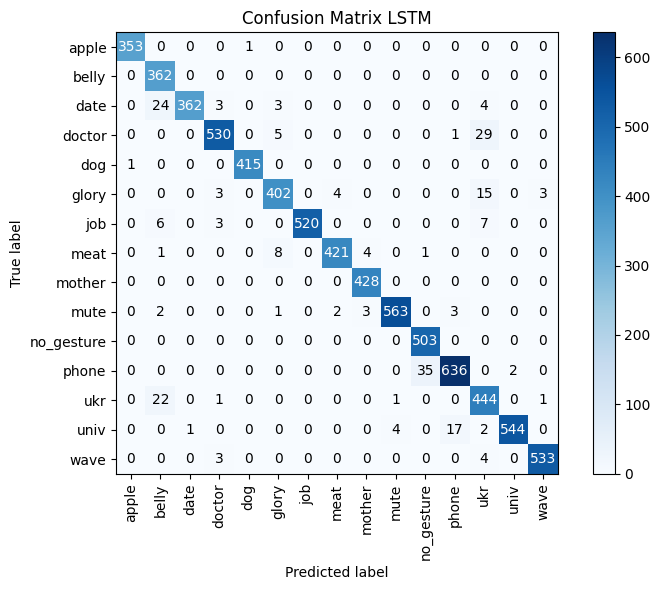

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_idx,
    y_pred_idx,
    labels=np.arange(len(classes))
)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix LSTM")
plt.colorbar()

ticks = np.arange(len(classes))
plt.xticks(ticks, classes, rotation=90)
plt.yticks(ticks, classes)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

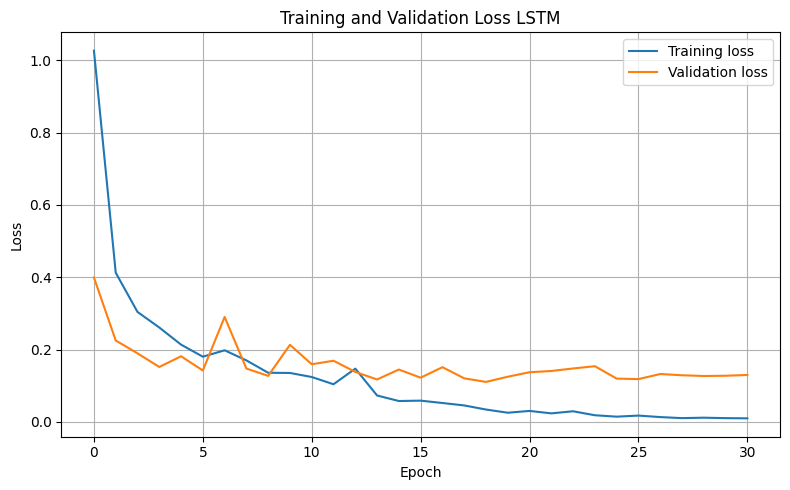

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Training and Validation Loss LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

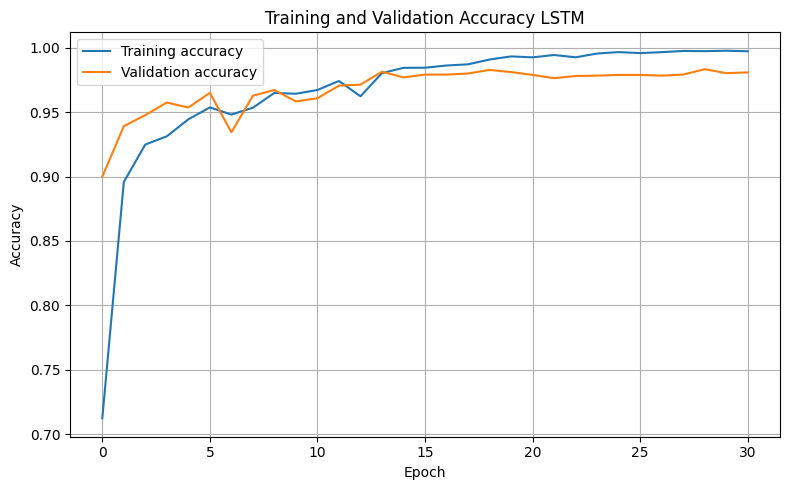

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Training and Validation Accuracy LSTM")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os
import json
import pickle
from collections import Counter
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import tensorflow as tf


# ============================================================
# Пути
# ============================================================
MODEL_PATH = "artifacts/LSTM/final_lstm_model.keras"
SCALER_PATH = "artifacts/LSTM/scaler.pkl"
LABELS_PATH = "artifacts/LSTM/labels.json"
CONFIG_PATH = "artifacts/LSTM/config.json"

# Можно указать либо файл, либо папку
#INPUT_PATH = "drive/MyDrive/test_csv"
INPUT_PATH = "drive/MyDrive/test"   # например папка с новыми csv


# ============================================================
# Алиасы колонок
# ============================================================
COLUMN_ALIASES: Dict[str, Tuple[str, ...]] = {
    "timestamp": ("timestamp", "t_ms", "time", "ts"),
    "flex_thumb": ("flex_thumb", "flex1", "thumb"),
    "flex_index": ("flex_index", "flex2", "index"),
    "flex_middle": ("flex_middle", "flex3", "middle"),
    "flex_ring": ("flex_ring", "flex4", "ring"),
    "flex_little": ("flex_little", "flex5", "little", "pinky"),
    "accX": ("accX", "ax", "accx"),
    "accY": ("accY", "ay", "accy"),
    "accZ": ("accZ", "az", "accz"),
    "gyroX": ("gyroX", "gx", "gyrox"),
    "gyroY": ("gyroY", "gy", "gyroy"),
    "gyroZ": ("gyroZ", "gz", "gyroz"),
    "label": ("label", "gesture", "class", "word"),
}


# ============================================================
# Вспомогательные функции
# ============================================================
def normalize_key(text: str) -> str:
    return "".join(ch for ch in str(text).lower() if ch.isalnum())


def find_matching_column(columns: Iterable[str], aliases: Iterable[str]) -> str | None:
    normalized = {normalize_key(col): col for col in columns}
    for alias in aliases:
        key = normalize_key(alias)
        if key in normalized:
            return normalized[key]
    return None


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map: Dict[str, str] = {}
    for canonical, aliases in COLUMN_ALIASES.items():
        if canonical in df.columns:
            continue
        match = find_matching_column(df.columns, aliases)
        if match is not None and match not in rename_map:
            rename_map[match] = canonical
    if rename_map:
        df = df.rename(columns=rename_map)
    return df


def sort_by_timestamp_if_possible(df: pd.DataFrame, timestamp_col: str) -> pd.DataFrame:
    if timestamp_col not in df.columns:
        return df

    ts_raw = df[timestamp_col]

    ts_numeric = pd.to_numeric(ts_raw, errors="coerce")
    if ts_numeric.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_numeric).sort_values("__ts_sort").drop(columns="__ts_sort")

    ts_datetime = pd.to_datetime(ts_raw, errors="coerce")
    if ts_datetime.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_datetime).sort_values("__ts_sort").drop(columns="__ts_sort")

    return df


def load_artifacts():
    model = tf.keras.models.load_model(MODEL_PATH)

    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)

    with open(LABELS_PATH, "r", encoding="utf-8") as f:
        class_to_index = json.load(f)

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = json.load(f)

    index_to_class = {v: k for k, v in class_to_index.items()}

    return model, scaler, class_to_index, index_to_class, config


def clean_dataframe(df: pd.DataFrame, features: List[str], timestamp_col: str) -> pd.DataFrame:
    df = standardize_columns(df)
    df = sort_by_timestamp_if_possible(df, timestamp_col).copy()

    missing = [col for col in features if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df[features] = df[features].apply(pd.to_numeric, errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=features).reset_index(drop=True)

    if df.empty:
        raise ValueError("No valid rows left after cleaning.")

    return df


def create_windows(values: np.ndarray, sequence_length: int, sequence_step: int) -> np.ndarray:
    windows = []
    for start in range(0, len(values) - sequence_length + 1, sequence_step):
        end = start + sequence_length
        windows.append(values[start:end])

    if not windows:
        return np.empty((0, sequence_length, values.shape[1]), dtype=np.float32)

    return np.asarray(windows, dtype=np.float32)


def scale_windows(X: np.ndarray, scaler) -> np.ndarray:
    n_samples, seq_len, n_features = X.shape
    X2 = scaler.transform(X.reshape(n_samples * seq_len, n_features))
    return X2.reshape(n_samples, seq_len, n_features).astype(np.float32)


def predict_file(csv_path: str, model, scaler, index_to_class, config):
    sequence_length = int(config["sequence_length"])
    sequence_step = int(config["sequence_step"])
    features = list(config["features"])
    timestamp_col = config.get("timestamp_col", "timestamp")

    df = pd.read_csv(csv_path)
    df = clean_dataframe(df, features, timestamp_col)

    values = df[features].to_numpy(dtype=np.float32)
    windows = create_windows(values, sequence_length, sequence_step)

    if len(windows) == 0:
        print(f"\n{os.path.basename(csv_path)}")
        print(f"  Недостаточно строк: нужно минимум {sequence_length}, а в файле {len(df)}")
        return

    windows_scaled = scale_windows(windows, scaler)
    probs = model.predict(windows_scaled, verbose=0)
    pred_idx = np.argmax(probs, axis=1)

    pred_labels = [index_to_class[int(i)] for i in pred_idx]
    pred_conf = np.max(probs, axis=1)

    counts = Counter(pred_labels)
    final_label = counts.most_common(1)[0][0]
    mean_conf = float(np.mean(pred_conf))

    print(f"\nФайл: {os.path.basename(csv_path)}")
    print(f"  Вікон: {len(windows)}")
    print(f"  Передбачення по вікнам: {dict(counts)}")
    print(f"  Результат по файлу: {final_label}")
    print(f"  Середня впевненість: {mean_conf:.4f}")

    print("  Перші 20 вікон:")
    for i, (label, conf) in enumerate(list(zip(pred_labels, pred_conf))[:20], start=1):
        print(f"    вікно {i}: {label:12s} conf={conf:.4f}")


def get_csv_files(path: str) -> List[str]:
    if os.path.isfile(path) and path.lower().endswith(".csv"):
        return [path]

    if os.path.isdir(path):
        files = [
            os.path.join(path, name)
            for name in sorted(os.listdir(path))
            if name.lower().endswith(".csv")
        ]
        return files

    raise FileNotFoundError(f"Path not found: {path}")


def main():
    model, scaler, class_to_index, index_to_class, config = load_artifacts()

    print("Loaded classes:")
    print(index_to_class)

    csv_files = get_csv_files(INPUT_PATH)
    if not csv_files:
        print("CSV files not found.")
        return

    for csv_path in csv_files:
        try:
            predict_file(csv_path, model, scaler, index_to_class, config)
        except Exception as e:
            print(f"\nФайл: {os.path.basename(csv_path)}")
            print(f"  Ошибка: {e}")


if __name__ == "__main__":
    main()

Loaded classes:
{0: 'apple', 1: 'belly', 2: 'date', 3: 'doctor', 4: 'dog', 5: 'glory', 6: 'job', 7: 'meat', 8: 'mother', 9: 'mute', 10: 'no_gesture', 11: 'phone', 12: 'ukr', 13: 'univ', 14: 'wave'}

Файл: apple_s01_r101.csv
  Вікон: 47
  Передбачення по вікнам: {'apple': 47}
  Результат по файлу: apple
  Середня впевненість: 0.9999
  Перші 20 вікон:
    вікно 1: apple        conf=0.9999
    вікно 2: apple        conf=0.9999
    вікно 3: apple        conf=0.9999
    вікно 4: apple        conf=0.9999
    вікно 5: apple        conf=0.9999
    вікно 6: apple        conf=0.9999
    вікно 7: apple        conf=0.9999
    вікно 8: apple        conf=0.9999
    вікно 9: apple        conf=1.0000
    вікно 10: apple        conf=1.0000
    вікно 11: apple        conf=1.0000
    вікно 12: apple        conf=1.0000
    вікно 13: apple        conf=1.0000
    вікно 14: apple        conf=0.9999
    вікно 15: apple        conf=0.9999
    вікно 16: apple        conf=0.9999
    вікно 17: apple        conf=0

In [1]:
import json
import os
from collections import Counter
from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple

import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Embedding,
)
from tensorflow.keras.models import Model


@dataclass
class Config:
    data_dir: str = "drive/MyDrive/dataset_csv"
    model_dir: str = "artifacts"

    sequence_length: int = 50
    sequence_step: int = 10

    test_size: float = 0.2
    val_size: float = 0.1
    random_state: int = 42

    batch_size: int = 32
    epochs: int = 80
    learning_rate: float = 1e-3
    use_class_weights: bool = True

    # Transformer parameters
    d_model: int = 64
    num_heads: int = 4
    ff_dim: int = 128
    num_transformer_blocks: int = 2
    transformer_dropout: float = 0.2

    features: Tuple[str, ...] = (
        "flex_thumb",
        "flex_index",
        "flex_middle",
        "flex_ring",
        "flex_little",
        "accX",
        "accY",
        "accZ",
        "gyroX",
        "gyroY",
        "gyroZ",
    )

    label_col: str = "label"
    timestamp_col: str = "timestamp"


CFG = Config()


COLUMN_ALIASES: Dict[str, Tuple[str, ...]] = {
    "timestamp": ("timestamp", "t_ms", "time", "ts"),
    "flex_thumb": ("flex_thumb", "flex1", "thumb"),
    "flex_index": ("flex_index", "flex2", "index"),
    "flex_middle": ("flex_middle", "flex3", "middle"),
    "flex_ring": ("flex_ring", "flex4", "ring"),
    "flex_little": ("flex_little", "flex5", "little", "pinky"),
    "accX": ("accX", "ax", "accx"),
    "accY": ("accY", "ay", "accy"),
    "accZ": ("accZ", "az", "accz"),
    "gyroX": ("gyroX", "gx", "gyrox"),
    "gyroY": ("gyroY", "gy", "gyroy"),
    "gyroZ": ("gyroZ", "gz", "gyroz"),
    "label": ("label", "gesture", "class", "word"),
}


def normalize_key(text: str) -> str:
    return "".join(ch for ch in str(text).lower() if ch.isalnum())


def ensure_dirs() -> None:
    os.makedirs(CFG.model_dir, exist_ok=True)


def seed_everything(seed: int) -> None:
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def find_matching_column(columns: Iterable[str], aliases: Iterable[str]) -> str | None:
    normalized = {normalize_key(col): col for col in columns}
    for alias in aliases:
        key = normalize_key(alias)
        if key in normalized:
            return normalized[key]
    return None


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map: Dict[str, str] = {}

    for canonical, aliases in COLUMN_ALIASES.items():
        if canonical in df.columns:
            continue

        match = find_matching_column(df.columns, aliases)
        if match is not None and match not in rename_map:
            rename_map[match] = canonical

    if rename_map:
        df = df.rename(columns=rename_map)

    return df


def load_csv_files(data_dir: str) -> List[pd.DataFrame]:
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory '{data_dir}' was not found.")

    csv_files = sorted(
        os.path.join(data_dir, filename)
        for filename in os.listdir(data_dir)
        if filename.lower().endswith(".csv")
    )

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in '{data_dir}'.")

    dataframes: List[pd.DataFrame] = []

    for path in csv_files:
        df = pd.read_csv(path)
        df["__source_file"] = os.path.basename(path)
        df = standardize_columns(df)
        dataframes.append(df)

    return dataframes


def sort_by_timestamp_if_possible(df: pd.DataFrame) -> pd.DataFrame:
    if CFG.timestamp_col not in df.columns:
        return df

    ts_raw = df[CFG.timestamp_col]

    ts_numeric = pd.to_numeric(ts_raw, errors="coerce")
    if ts_numeric.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_numeric).sort_values("__ts_sort").drop(columns="__ts_sort")

    ts_datetime = pd.to_datetime(ts_raw, errors="coerce")
    if ts_datetime.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_datetime).sort_values("__ts_sort").drop(columns="__ts_sort")

    return df


def validate_and_clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    required_columns = set(CFG.features) | {CFG.label_col}
    missing = required_columns - set(df.columns)

    if missing:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"Missing columns in {source}: {sorted(missing)}")

    df = sort_by_timestamp_if_possible(df).copy()

    df[list(CFG.features)] = df[list(CFG.features)].apply(pd.to_numeric, errors="coerce")
    df[CFG.label_col] = df[CFG.label_col].astype(str).str.strip()

    df = df.replace([np.inf, -np.inf], np.nan)

    valid_mask = (
        df[list(CFG.features)].notna().all(axis=1)
        & df[CFG.label_col].ne("")
        & df[CFG.label_col].notna()
    )

    cleaned = df.loc[valid_mask].reset_index(drop=True)

    if cleaned.empty:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"After cleaning there are no valid rows left in {source}.")

    return cleaned


def split_contiguous_label_segments(df: pd.DataFrame) -> List[pd.DataFrame]:
    labels = df[CFG.label_col].astype(str)
    segment_ids = labels.ne(labels.shift(1)).cumsum()

    return [
        segment.reset_index(drop=True)
        for _, segment in df.groupby(segment_ids, sort=False)
    ]


def create_sequences_from_segment(
    segment: pd.DataFrame,
    source_group: str,
    sequence_length: int,
    sequence_step: int,
) -> Tuple[List[np.ndarray], List[str], List[str]]:

    values = segment[list(CFG.features)].to_numpy(dtype=np.float32)
    label = segment[CFG.label_col].iloc[0]

    X_list: List[np.ndarray] = []
    y_list: List[str] = []
    g_list: List[str] = []

    if len(values) < sequence_length:
        return X_list, y_list, g_list

    for start in range(0, len(values) - sequence_length + 1, sequence_step):
        end = start + sequence_length

        X_list.append(values[start:end])
        y_list.append(label)
        g_list.append(source_group)

    return X_list, y_list, g_list


def build_dataset(dataframes: List[pd.DataFrame]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    X_all: List[np.ndarray] = []
    y_all: List[str] = []
    g_all: List[str] = []

    for df in dataframes:
        cleaned = validate_and_clean_dataframe(df)
        source = cleaned["__source_file"].iloc[0]

        segments = split_contiguous_label_segments(cleaned)

        for idx, segment in enumerate(segments):
            group_id = f"{source}::seg_{idx}"

            x_part, y_part, g_part = create_sequences_from_segment(
                segment=segment,
                source_group=group_id,
                sequence_length=CFG.sequence_length,
                sequence_step=CFG.sequence_step,
            )

            X_all.extend(x_part)
            y_all.extend(y_part)
            g_all.extend(g_part)

    if not X_all:
        raise ValueError("No sequences were created. Check sequence_length and dataset size.")

    X = np.asarray(X_all, dtype=np.float32)
    y_text = np.asarray(y_all, dtype=str)
    groups = np.asarray(g_all, dtype=str)

    classes = sorted(np.unique(y_text).tolist())

    if len(classes) < 2:
        raise ValueError("Need at least 2 gesture classes for training.")

    return X, y_text, groups, classes


def encode_labels(y_text: np.ndarray, classes: List[str]) -> Tuple[np.ndarray, Dict[str, int]]:
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_idx = np.asarray([class_to_index[label] for label in y_text], dtype=np.int32)

    return y_idx, class_to_index


def fit_scaler_on_train(X_train: np.ndarray) -> StandardScaler:
    n_samples, seq_len, n_features = X_train.shape

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(n_samples * seq_len, n_features))

    return scaler


def apply_scaler(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    n_samples, seq_len, n_features = X.shape

    scaled = scaler.transform(X.reshape(n_samples * seq_len, n_features))

    return scaled.reshape(n_samples, seq_len, n_features).astype(np.float32)


def label_per_group(groups: np.ndarray, y_idx: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    unique_groups = np.unique(groups)
    group_labels = np.zeros(len(unique_groups), dtype=np.int32)

    for i, group in enumerate(unique_groups):
        labels = y_idx[groups == group]
        group_labels[i] = Counter(labels.tolist()).most_common(1)[0][0]

    return unique_groups, group_labels


def split_indices_group_aware(
    groups: np.ndarray,
    y_idx: np.ndarray,
    holdout_size: float,
    random_state: int,
) -> Tuple[np.ndarray, np.ndarray]:

    unique_groups, group_labels = label_per_group(groups, y_idx)

    if len(unique_groups) < 2:
        raise ValueError("Need at least 2 independent recordings/groups for splitting.")

    stratify_labels = None
    per_class_counts = Counter(group_labels.tolist())

    if min(per_class_counts.values()) >= 2:
        stratify_labels = group_labels
    else:
        print("[warn] Group stratification disabled (some classes have <2 groups).")

    try:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=stratify_labels,
        )
    except ValueError:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=None,
        )

        print("[warn] Fallback split without stratification.")

    train_mask = np.isin(groups, train_groups)
    holdout_mask = np.isin(groups, holdout_groups)

    return np.where(train_mask)[0], np.where(holdout_mask)[0]


def class_distribution_text(y_idx: np.ndarray, classes: List[str]) -> str:
    counts = np.bincount(y_idx, minlength=len(classes))

    return ", ".join(
        f"{classes[i]}={int(counts[i])}"
        for i in range(len(classes))
    )


def transformer_encoder_block(
    x: tf.Tensor,
    d_model: int,
    num_heads: int,
    ff_dim: int,
    dropout_rate: float,
) -> tf.Tensor:

    key_dim = d_model // num_heads

    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout_rate,
    )(x, x)

    attention_output = Dropout(dropout_rate)(attention_output)

    x = LayerNormalization(epsilon=1e-6)(x + attention_output)

    ffn_output = Dense(ff_dim, activation="relu")(x)
    ffn_output = Dropout(dropout_rate)(ffn_output)
    ffn_output = Dense(d_model)(ffn_output)

    x = LayerNormalization(epsilon=1e-6)(x + ffn_output)

    return x


def build_model(
    sequence_length: int,
    n_features: int,
    n_classes: int,
) -> tf.keras.Model:

    inputs = Input(shape=(sequence_length, n_features))

    x = Dense(CFG.d_model)(inputs)

    positions = tf.range(start=0, limit=sequence_length, delta=1)
    position_embedding = Embedding(
        input_dim=sequence_length,
        output_dim=CFG.d_model,
    )(positions)

    x = x + position_embedding

    for _ in range(CFG.num_transformer_blocks):
        x = transformer_encoder_block(
            x=x,
            d_model=CFG.d_model,
            num_heads=CFG.num_heads,
            ff_dim=CFG.ff_dim,
            dropout_rate=CFG.transformer_dropout,
        )

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(n_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def compute_class_weights(y_idx: np.ndarray) -> Dict[int, float] | None:
    if not CFG.use_class_weights:
        return None

    present = np.unique(y_idx)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=present,
        y=y_idx,
    )

    return {
        int(cls): float(weight)
        for cls, weight in zip(present, weights)
    }


def main():
    seed_everything(CFG.random_state)
    ensure_dirs()

    print("[1/8] Loading CSV files...")
    dataframes = load_csv_files(CFG.data_dir)

    print("[2/8] Building sequence dataset...")
    X, y_text, groups, classes = build_dataset(dataframes)
    y_idx, class_to_index = encode_labels(y_text, classes)

    print(f"Total windows: {len(X)}")
    print(f"Classes: {classes}")
    print(f"X shape: {X.shape}")
    print(f"Windows per class: {class_distribution_text(y_idx, classes)}")

    print("[3/8] Group-aware split train+val / test...")
    trainval_idx, test_idx = split_indices_group_aware(
        groups=groups,
        y_idx=y_idx,
        holdout_size=CFG.test_size,
        random_state=CFG.random_state,
    )

    X_trainval, X_test = X[trainval_idx], X[test_idx]
    y_trainval_idx, y_test_idx = y_idx[trainval_idx], y_idx[test_idx]
    groups_trainval = groups[trainval_idx]

    relative_val = CFG.val_size / (1.0 - CFG.test_size)
    relative_val = min(max(relative_val, 0.05), 0.5)

    print("[4/8] Group-aware split train / val...")
    train_idx_local, val_idx_local = split_indices_group_aware(
        groups=groups_trainval,
        y_idx=y_trainval_idx,
        holdout_size=relative_val,
        random_state=CFG.random_state + 1,
    )

    X_train, X_val = X_trainval[train_idx_local], X_trainval[val_idx_local]
    y_train_idx, y_val_idx = y_trainval_idx[train_idx_local], y_trainval_idx[val_idx_local]

    print(f"Train class distribution: {class_distribution_text(y_train_idx, classes)}")
    print(f"Val class distribution: {class_distribution_text(y_val_idx, classes)}")
    print(f"Test class distribution: {class_distribution_text(y_test_idx, classes)}")

    print("[5/8] Scaling features...")
    scaler = fit_scaler_on_train(X_train)

    X_train = apply_scaler(X_train, scaler)
    X_val = apply_scaler(X_val, scaler)
    X_test = apply_scaler(X_test, scaler)

    print("[6/8] Building Transformer model...")
    model = build_model(
        sequence_length=CFG.sequence_length,
        n_features=len(CFG.features),
        n_classes=len(classes),
    )

    model.summary()

    checkpoint_path = os.path.join(CFG.model_dir, "best_transformer_model.keras")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=12,
            restore_best_weights=True,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    class_weight = compute_class_weights(y_train_idx)

    if class_weight is not None:
        print(f"Class weights: {class_weight}")

    print("[7/8] Training...")
    history = model.fit(
        X_train,
        y_train_idx,
        validation_data=(X_val, y_val_idx),
        epochs=CFG.epochs,
        batch_size=CFG.batch_size,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )

    print("[8/8] Evaluation...")
    test_loss, test_acc = model.evaluate(X_test, y_test_idx, verbose=0)

    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred_idx = np.argmax(y_pred_prob, axis=1)

    all_labels = list(range(len(classes)))

    print("\nClassification report:\n")
    print(
        classification_report(
            y_test_idx,
            y_pred_idx,
            labels=all_labels,
            target_names=classes,
            zero_division=0,
            digits=4,
        )
    )

    print("Confusion matrix:")
    print(confusion_matrix(y_test_idx, y_pred_idx, labels=all_labels))

    final_model_path = os.path.join(CFG.model_dir, "final_transformer_model.keras")
    scaler_path = os.path.join(CFG.model_dir, "scaler.pkl")
    labels_path = os.path.join(CFG.model_dir, "labels.json")
    config_path = os.path.join(CFG.model_dir, "config.json")

    model.save(final_model_path)

    with open(scaler_path, "wb") as file:
        pickle.dump(scaler, file)

    with open(labels_path, "w", encoding="utf-8") as file:
        json.dump(class_to_index, file, ensure_ascii=False, indent=2)

    with open(config_path, "w", encoding="utf-8") as file:
        json.dump(
            {
                "model_type": "Transformer Encoder",
                "sequence_length": CFG.sequence_length,
                "sequence_step": CFG.sequence_step,
                "features": list(CFG.features),
                "classes": classes,
                "column_aliases": COLUMN_ALIASES,
                "d_model": CFG.d_model,
                "num_heads": CFG.num_heads,
                "ff_dim": CFG.ff_dim,
                "num_transformer_blocks": CFG.num_transformer_blocks,
                "transformer_dropout": CFG.transformer_dropout,
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("\nArtifacts saved to:", CFG.model_dir)
    print("- model:", final_model_path)
    print("- scaler:", scaler_path)
    print("- labels:", labels_path)
    print("- config:", config_path)

    return history, classes, y_test_idx, y_pred_idx


if __name__ == "__main__":
    history, classes, y_test_idx, y_pred_idx = main()

[1/8] Loading CSV files...
[2/8] Building sequence dataset...
Total windows: 36892
Classes: ['apple', 'belly', 'date', 'doctor', 'dog', 'glory', 'job', 'meat', 'mother', 'mute', 'no_gesture', 'phone', 'ukr', 'univ', 'wave']
X shape: (36892, 50, 11)
Windows per class: apple=1873, belly=1922, date=1866, doctor=2740, dog=2140, glory=1968, job=2810, meat=2222, mother=2220, mute=3089, no_gesture=2541, phone=3425, ukr=2453, univ=2892, wave=2731
[3/8] Group-aware split train+val / test...
[4/8] Group-aware split train / val...
Train class distribution: apple=1310, belly=1375, date=1299, doctor=1946, dog=1535, glory=1353, job=1998, meat=1573, mother=1521, mute=2186, no_gesture=1798, phone=2413, ukr=1731, univ=2083, wave=1930
Val class distribution: apple=209, belly=185, date=171, doctor=229, dog=189, glory=188, job=276, meat=214, mother=271, mute=329, no_gesture=240, phone=339, ukr=253, univ=241, wave=261
Test class distribution: apple=354, belly=362, date=396, doctor=565, dog=416, glory=427, 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 64)    │        768 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 50, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 50, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 50, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 50, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50, 64)    │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]   

 Total params: 74,447 (290.81 KB)

 Trainable params: 74,447 (290.81 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: 1.3257506361323155, 1: 1.263078787878788, 2: 1.3369771619194253, 3: 0.8924631723192874, 4: 1.1314223669923995, 5: 1.2836166543483616, 6: 0.8692359025692359, 7: 1.104089849544395, 8: 1.1418365110672803, 9: 0.7944800243976822, 10: 0.9659251019651465, 11: 0.7197402956209421, 12: 1.003312150972463, 13: 0.8337654024643943, 14: 0.8998618307426598}
[7/8] Training...
Epoch 1/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 114s 129ms/step - accuracy: 0.7893 - loss: 0.6771 - val_accuracy: 0.9449 - val_loss: 0.1949 - learning_rate: 0.0010
Epoch 2/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9241 - loss: 0.2590 - val_accuracy: 0.9630 - val_loss: 0.1034 - learning_rate: 0.0010
Epoch 3/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9439 - loss: 0.1872 - val_accuracy: 0.9663 - val_loss: 0.0905 - learning_rate: 0.0010
Epoch 4/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 140s 99ms/step - accuracy: 0.9555 - loss: 0.1477 - val_accuracy: 0.9627 - val_loss: 0.1162 - learning_rate: 0.001

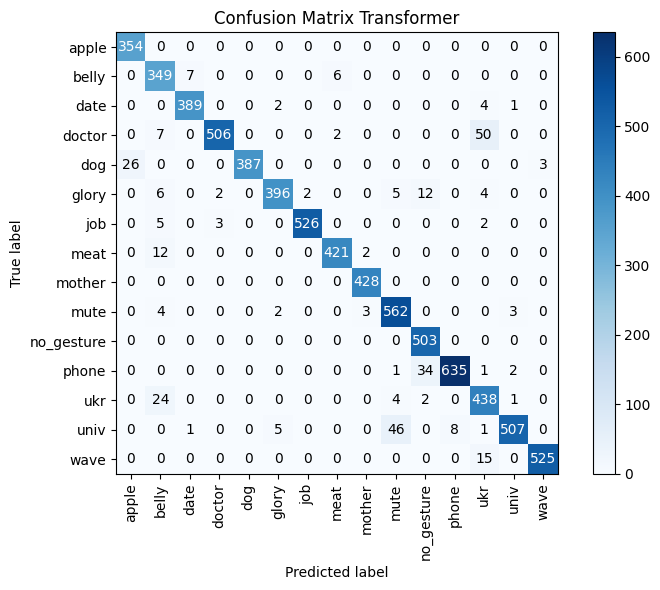

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_idx,
    y_pred_idx,
    labels=np.arange(len(classes))
)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix Transformer")
plt.colorbar()

ticks = np.arange(len(classes))
plt.xticks(ticks, classes, rotation=90)
plt.yticks(ticks, classes)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("transformer_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

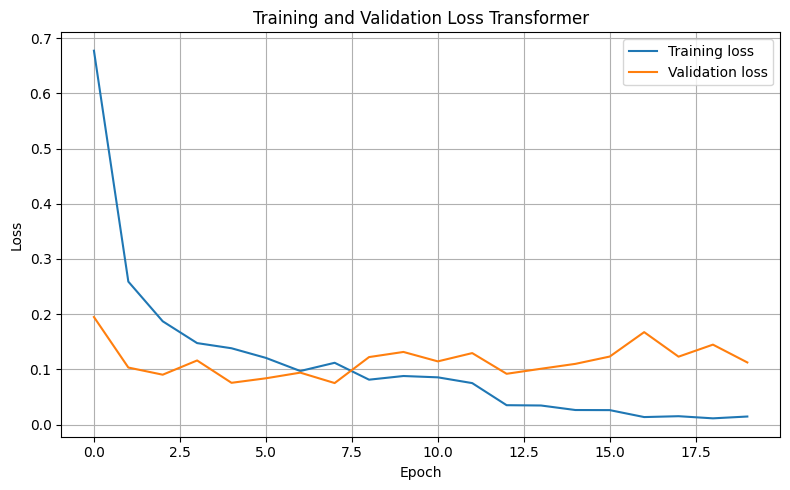

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Training and Validation Loss Transformer")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transformer_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

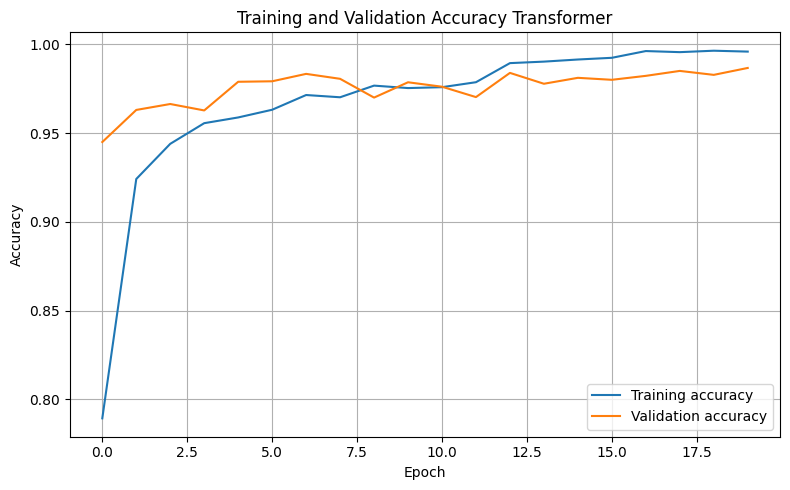

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Training and Validation Accuracy Transformer")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transformer_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
import json
import os
from collections import Counter
from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple

import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    GlobalAveragePooling1D,
)
from tensorflow.keras.models import Model


@dataclass
class Config:
    data_dir: str = "drive/MyDrive/dataset_csv"
    model_dir: str = "artifacts/TCN"

    sequence_length: int = 50
    sequence_step: int = 10

    test_size: float = 0.2
    val_size: float = 0.1
    random_state: int = 42

    batch_size: int = 32
    epochs: int = 80
    learning_rate: float = 1e-3
    use_class_weights: bool = True

    # TCN parameters
    tcn_filters: int = 64
    tcn_kernel_size: int = 3
    tcn_dilations: Tuple[int, ...] = (1, 2, 4, 8)
    tcn_dropout: float = 0.2

    features: Tuple[str, ...] = (
        "flex_thumb",
        "flex_index",
        "flex_middle",
        "flex_ring",
        "flex_little",
        "accX",
        "accY",
        "accZ",
        "gyroX",
        "gyroY",
        "gyroZ",
    )

    label_col: str = "label"
    timestamp_col: str = "timestamp"


CFG = Config()


COLUMN_ALIASES: Dict[str, Tuple[str, ...]] = {
    "timestamp": ("timestamp", "t_ms", "time", "ts"),
    "flex_thumb": ("flex_thumb", "flex1", "thumb"),
    "flex_index": ("flex_index", "flex2", "index"),
    "flex_middle": ("flex_middle", "flex3", "middle"),
    "flex_ring": ("flex_ring", "flex4", "ring"),
    "flex_little": ("flex_little", "flex5", "little", "pinky"),
    "accX": ("accX", "ax", "accx"),
    "accY": ("accY", "ay", "accy"),
    "accZ": ("accZ", "az", "accz"),
    "gyroX": ("gyroX", "gx", "gyrox"),
    "gyroY": ("gyroY", "gy", "gyroy"),
    "gyroZ": ("gyroZ", "gz", "gyroz"),
    "label": ("label", "gesture", "class", "word"),
}


def normalize_key(text: str) -> str:
    return "".join(ch for ch in str(text).lower() if ch.isalnum())


def ensure_dirs() -> None:
    os.makedirs(CFG.model_dir, exist_ok=True)


def seed_everything(seed: int) -> None:
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def find_matching_column(columns: Iterable[str], aliases: Iterable[str]) -> str | None:
    normalized = {normalize_key(col): col for col in columns}
    for alias in aliases:
        key = normalize_key(alias)
        if key in normalized:
            return normalized[key]
    return None


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map: Dict[str, str] = {}

    for canonical, aliases in COLUMN_ALIASES.items():
        if canonical in df.columns:
            continue

        match = find_matching_column(df.columns, aliases)
        if match is not None and match not in rename_map:
            rename_map[match] = canonical

    if rename_map:
        df = df.rename(columns=rename_map)

    return df


def load_csv_files(data_dir: str) -> List[pd.DataFrame]:
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f"Directory '{data_dir}' was not found.")

    csv_files = sorted(
        os.path.join(data_dir, filename)
        for filename in os.listdir(data_dir)
        if filename.lower().endswith(".csv")
    )

    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in '{data_dir}'.")

    dataframes: List[pd.DataFrame] = []

    for path in csv_files:
        df = pd.read_csv(path)
        df["__source_file"] = os.path.basename(path)
        df = standardize_columns(df)
        dataframes.append(df)

    return dataframes


def sort_by_timestamp_if_possible(df: pd.DataFrame) -> pd.DataFrame:
    if CFG.timestamp_col not in df.columns:
        return df

    ts_raw = df[CFG.timestamp_col]

    ts_numeric = pd.to_numeric(ts_raw, errors="coerce")
    if ts_numeric.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_numeric).sort_values("__ts_sort").drop(columns="__ts_sort")

    ts_datetime = pd.to_datetime(ts_raw, errors="coerce")
    if ts_datetime.notna().sum() >= len(df) * 0.8:
        return df.assign(__ts_sort=ts_datetime).sort_values("__ts_sort").drop(columns="__ts_sort")

    return df


def validate_and_clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    required_columns = set(CFG.features) | {CFG.label_col}
    missing = required_columns - set(df.columns)

    if missing:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"Missing columns in {source}: {sorted(missing)}")

    df = sort_by_timestamp_if_possible(df).copy()

    df[list(CFG.features)] = df[list(CFG.features)].apply(pd.to_numeric, errors="coerce")
    df[CFG.label_col] = df[CFG.label_col].astype(str).str.strip()

    df = df.replace([np.inf, -np.inf], np.nan)

    valid_mask = (
        df[list(CFG.features)].notna().all(axis=1)
        & df[CFG.label_col].ne("")
        & df[CFG.label_col].notna()
    )

    cleaned = df.loc[valid_mask].reset_index(drop=True)

    if cleaned.empty:
        source = df["__source_file"].iloc[0] if "__source_file" in df.columns and len(df) else "unknown"
        raise ValueError(f"After cleaning there are no valid rows left in {source}.")

    return cleaned


def split_contiguous_label_segments(df: pd.DataFrame) -> List[pd.DataFrame]:
    labels = df[CFG.label_col].astype(str)
    segment_ids = labels.ne(labels.shift(1)).cumsum()

    return [
        segment.reset_index(drop=True)
        for _, segment in df.groupby(segment_ids, sort=False)
    ]


def create_sequences_from_segment(
    segment: pd.DataFrame,
    source_group: str,
    sequence_length: int,
    sequence_step: int,
) -> Tuple[List[np.ndarray], List[str], List[str]]:

    values = segment[list(CFG.features)].to_numpy(dtype=np.float32)
    label = segment[CFG.label_col].iloc[0]

    X_list: List[np.ndarray] = []
    y_list: List[str] = []
    g_list: List[str] = []

    if len(values) < sequence_length:
        return X_list, y_list, g_list

    for start in range(0, len(values) - sequence_length + 1, sequence_step):
        end = start + sequence_length

        X_list.append(values[start:end])
        y_list.append(label)
        g_list.append(source_group)

    return X_list, y_list, g_list


def build_dataset(dataframes: List[pd.DataFrame]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    X_all: List[np.ndarray] = []
    y_all: List[str] = []
    g_all: List[str] = []

    for df in dataframes:
        cleaned = validate_and_clean_dataframe(df)
        source = cleaned["__source_file"].iloc[0]

        segments = split_contiguous_label_segments(cleaned)

        for idx, segment in enumerate(segments):
            group_id = f"{source}::seg_{idx}"

            x_part, y_part, g_part = create_sequences_from_segment(
                segment=segment,
                source_group=group_id,
                sequence_length=CFG.sequence_length,
                sequence_step=CFG.sequence_step,
            )

            X_all.extend(x_part)
            y_all.extend(y_part)
            g_all.extend(g_part)

    if not X_all:
        raise ValueError("No sequences were created. Check sequence_length and dataset size.")

    X = np.asarray(X_all, dtype=np.float32)
    y_text = np.asarray(y_all, dtype=str)
    groups = np.asarray(g_all, dtype=str)

    classes = sorted(np.unique(y_text).tolist())

    if len(classes) < 2:
        raise ValueError("Need at least 2 gesture classes for training.")

    return X, y_text, groups, classes


def encode_labels(y_text: np.ndarray, classes: List[str]) -> Tuple[np.ndarray, Dict[str, int]]:
    class_to_index = {label: idx for idx, label in enumerate(classes)}
    y_idx = np.asarray([class_to_index[label] for label in y_text], dtype=np.int32)

    return y_idx, class_to_index


def fit_scaler_on_train(X_train: np.ndarray) -> StandardScaler:
    n_samples, seq_len, n_features = X_train.shape

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(n_samples * seq_len, n_features))

    return scaler


def apply_scaler(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    n_samples, seq_len, n_features = X.shape

    scaled = scaler.transform(X.reshape(n_samples * seq_len, n_features))

    return scaled.reshape(n_samples, seq_len, n_features).astype(np.float32)


def label_per_group(groups: np.ndarray, y_idx: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    unique_groups = np.unique(groups)
    group_labels = np.zeros(len(unique_groups), dtype=np.int32)

    for i, group in enumerate(unique_groups):
        labels = y_idx[groups == group]
        group_labels[i] = Counter(labels.tolist()).most_common(1)[0][0]

    return unique_groups, group_labels


def split_indices_group_aware(
    groups: np.ndarray,
    y_idx: np.ndarray,
    holdout_size: float,
    random_state: int,
) -> Tuple[np.ndarray, np.ndarray]:

    unique_groups, group_labels = label_per_group(groups, y_idx)

    if len(unique_groups) < 2:
        raise ValueError("Need at least 2 independent recordings/groups for splitting.")

    stratify_labels = None
    per_class_counts = Counter(group_labels.tolist())

    if min(per_class_counts.values()) >= 2:
        stratify_labels = group_labels
    else:
        print("[warn] Group stratification disabled (some classes have <2 groups).")

    try:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=stratify_labels,
        )
    except ValueError:
        train_groups, holdout_groups = train_test_split(
            unique_groups,
            test_size=holdout_size,
            random_state=random_state,
            shuffle=True,
            stratify=None,
        )

        print("[warn] Fallback split without stratification.")

    train_mask = np.isin(groups, train_groups)
    holdout_mask = np.isin(groups, holdout_groups)

    return np.where(train_mask)[0], np.where(holdout_mask)[0]


def class_distribution_text(y_idx: np.ndarray, classes: List[str]) -> str:
    counts = np.bincount(y_idx, minlength=len(classes))

    return ", ".join(
        f"{classes[i]}={int(counts[i])}"
        for i in range(len(classes))
    )


def tcn_residual_block(
    x: tf.Tensor,
    filters: int,
    kernel_size: int,
    dilation_rate: int,
    dropout_rate: float,
) -> tf.Tensor:

    shortcut = x

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
    )(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation_rate,
    )(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(dropout_rate)(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same",
        )(shortcut)

    x = Add()([shortcut, x])
    x = Activation("relu")(x)

    return x


def build_model(
    sequence_length: int,
    n_features: int,
    n_classes: int,
) -> tf.keras.Model:

    inputs = Input(shape=(sequence_length, n_features))

    x = inputs

    for dilation in CFG.tcn_dilations:
        x = tcn_residual_block(
            x=x,
            filters=CFG.tcn_filters,
            kernel_size=CFG.tcn_kernel_size,
            dilation_rate=dilation,
            dropout_rate=CFG.tcn_dropout,
        )

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(n_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CFG.learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


def compute_class_weights(y_idx: np.ndarray) -> Dict[int, float] | None:
    if not CFG.use_class_weights:
        return None

    present = np.unique(y_idx)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=present,
        y=y_idx,
    )

    return {
        int(cls): float(weight)
        for cls, weight in zip(present, weights)
    }


def main():
    seed_everything(CFG.random_state)
    ensure_dirs()

    print("[1/8] Loading CSV files...")
    dataframes = load_csv_files(CFG.data_dir)

    print("[2/8] Building sequence dataset...")
    X, y_text, groups, classes = build_dataset(dataframes)
    y_idx, class_to_index = encode_labels(y_text, classes)

    print(f"Total windows: {len(X)}")
    print(f"Classes: {classes}")
    print(f"X shape: {X.shape}")
    print(f"Windows per class: {class_distribution_text(y_idx, classes)}")

    print("[3/8] Group-aware split train+val / test...")
    trainval_idx, test_idx = split_indices_group_aware(
        groups=groups,
        y_idx=y_idx,
        holdout_size=CFG.test_size,
        random_state=CFG.random_state,
    )

    X_trainval, X_test = X[trainval_idx], X[test_idx]
    y_trainval_idx, y_test_idx = y_idx[trainval_idx], y_idx[test_idx]
    groups_trainval = groups[trainval_idx]

    relative_val = CFG.val_size / (1.0 - CFG.test_size)
    relative_val = min(max(relative_val, 0.05), 0.5)

    print("[4/8] Group-aware split train / val...")
    train_idx_local, val_idx_local = split_indices_group_aware(
        groups=groups_trainval,
        y_idx=y_trainval_idx,
        holdout_size=relative_val,
        random_state=CFG.random_state + 1,
    )

    X_train, X_val = X_trainval[train_idx_local], X_trainval[val_idx_local]
    y_train_idx, y_val_idx = y_trainval_idx[train_idx_local], y_trainval_idx[val_idx_local]

    print(f"Train class distribution: {class_distribution_text(y_train_idx, classes)}")
    print(f"Val class distribution: {class_distribution_text(y_val_idx, classes)}")
    print(f"Test class distribution: {class_distribution_text(y_test_idx, classes)}")

    print("[5/8] Scaling features...")
    scaler = fit_scaler_on_train(X_train)

    X_train = apply_scaler(X_train, scaler)
    X_val = apply_scaler(X_val, scaler)
    X_test = apply_scaler(X_test, scaler)

    print("[6/8] Building TCN model...")
    model = build_model(
        sequence_length=CFG.sequence_length,
        n_features=len(CFG.features),
        n_classes=len(classes),
    )

    model.summary()

    checkpoint_path = os.path.join(CFG.model_dir, "best_tcn_model.keras")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=12,
            restore_best_weights=True,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-5,
        ),
        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    class_weight = compute_class_weights(y_train_idx)

    if class_weight is not None:
        print(f"Class weights: {class_weight}")

    print("[7/8] Training...")
    history = model.fit(
        X_train,
        y_train_idx,
        validation_data=(X_val, y_val_idx),
        epochs=CFG.epochs,
        batch_size=CFG.batch_size,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )

    print("[8/8] Evaluation...")
    test_loss, test_acc = model.evaluate(X_test, y_test_idx, verbose=0)

    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred_idx = np.argmax(y_pred_prob, axis=1)

    all_labels = list(range(len(classes)))

    print("\nClassification report:\n")
    print(
        classification_report(
            y_test_idx,
            y_pred_idx,
            labels=all_labels,
            target_names=classes,
            zero_division=0,
            digits=4,
        )
    )

    print("Confusion matrix:")
    print(confusion_matrix(y_test_idx, y_pred_idx, labels=all_labels))

    final_model_path = os.path.join(CFG.model_dir, "final_tcn_model.keras")
    scaler_path = os.path.join(CFG.model_dir, "scaler.pkl")
    labels_path = os.path.join(CFG.model_dir, "labels.json")
    config_path = os.path.join(CFG.model_dir, "config.json")

    model.save(final_model_path)

    with open(scaler_path, "wb") as file:
        pickle.dump(scaler, file)

    with open(labels_path, "w", encoding="utf-8") as file:
        json.dump(class_to_index, file, ensure_ascii=False, indent=2)

    with open(config_path, "w", encoding="utf-8") as file:
        json.dump(
            {
                "model_type": "TCN",
                "sequence_length": CFG.sequence_length,
                "sequence_step": CFG.sequence_step,
                "features": list(CFG.features),
                "classes": classes,
                "column_aliases": COLUMN_ALIASES,
                "tcn_filters": CFG.tcn_filters,
                "tcn_kernel_size": CFG.tcn_kernel_size,
                "tcn_dilations": CFG.tcn_dilations,
                "tcn_dropout": CFG.tcn_dropout,
            },
            file,
            ensure_ascii=False,
            indent=2,
        )

    print("\nArtifacts saved to:", CFG.model_dir)
    print("- model:", final_model_path)
    print("- scaler:", scaler_path)
    print("- labels:", labels_path)
    print("- config:", config_path)

    return history, classes, y_test_idx, y_pred_idx


if __name__ == "__main__":
    history, classes, y_test_idx, y_pred_idx = main()

[1/8] Loading CSV files...
[2/8] Building sequence dataset...
Total windows: 36892
Classes: ['apple', 'belly', 'date', 'doctor', 'dog', 'glory', 'job', 'meat', 'mother', 'mute', 'no_gesture', 'phone', 'ukr', 'univ', 'wave']
X shape: (36892, 50, 11)
Windows per class: apple=1873, belly=1922, date=1866, doctor=2740, dog=2140, glory=1968, job=2810, meat=2222, mother=2220, mute=3089, no_gesture=2541, phone=3425, ukr=2453, univ=2892, wave=2731
[3/8] Group-aware split train+val / test...
[4/8] Group-aware split train / val...
Train class distribution: apple=1310, belly=1375, date=1299, doctor=1946, dog=1535, glory=1353, job=1998, meat=1573, mother=1521, mute=2186, no_gesture=1798, phone=2413, ukr=1731, univ=2083, wave=1930
Val class distribution: apple=209, belly=185, date=171, doctor=229, dog=189, glory=188, job=276, meat=214, mother=271, mute=329, no_gesture=240, phone=339, ukr=253, univ=241, wave=261
Test class distribution: apple=354, belly=362, date=396, doctor=565, dog=416, glory=427, 

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 50, 64)    │      2,176 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 50, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 50, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 64)    │        768 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 50, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 50, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 50, 64)    │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 64)    │     12,352 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 50, 64)    │          0 │ activation_3[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 64)    │     12,352 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 50, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 50, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 98,191 (383.56 KB)

 Trainable params: 97,167 (379.56 KB)

 Non-trainable params: 1,024 (4.00 KB)

Class weights: {0: 1.3257506361323155, 1: 1.263078787878788, 2: 1.3369771619194253, 3: 0.8924631723192874, 4: 1.1314223669923995, 5: 1.2836166543483616, 6: 0.8692359025692359, 7: 1.104089849544395, 8: 1.1418365110672803, 9: 0.7944800243976822, 10: 0.9659251019651465, 11: 0.7197402956209421, 12: 1.003312150972463, 13: 0.8337654024643943, 14: 0.8998618307426598}
[7/8] Training...
Epoch 1/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 63s 66ms/step - accuracy: 0.7332 - loss: 0.8551 - val_accuracy: 0.9552 - val_loss: 0.1480 - learning_rate: 0.0010
Epoch 2/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - accuracy: 0.8956 - loss: 0.3493 - val_accuracy: 0.9344 - val_loss: 0.2242 - learning_rate: 0.0010
Epoch 3/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - accuracy: 0.9238 - loss: 0.2656 - val_accuracy: 0.9424 - val_loss: 0.2139 - learning_rate: 0.0010
Epoch 4/80
815/815 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - accuracy: 0.9388 - loss: 0.2061 - val_accuracy: 0.9566 - val_loss: 0.1381 - learning_rate: 0.0010
Epo

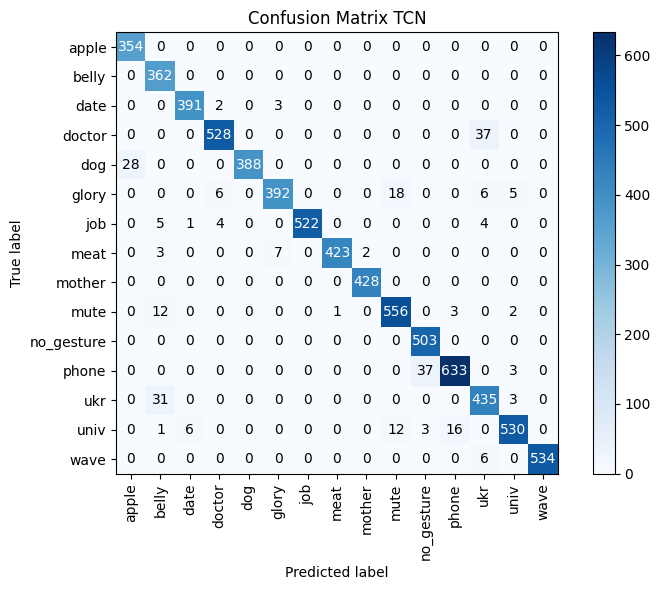

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_idx,
    y_pred_idx,
    labels=np.arange(len(classes))
)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix TCN")
plt.colorbar()

ticks = np.arange(len(classes))
plt.xticks(ticks, classes, rotation=90)
plt.yticks(ticks, classes)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("transformer_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

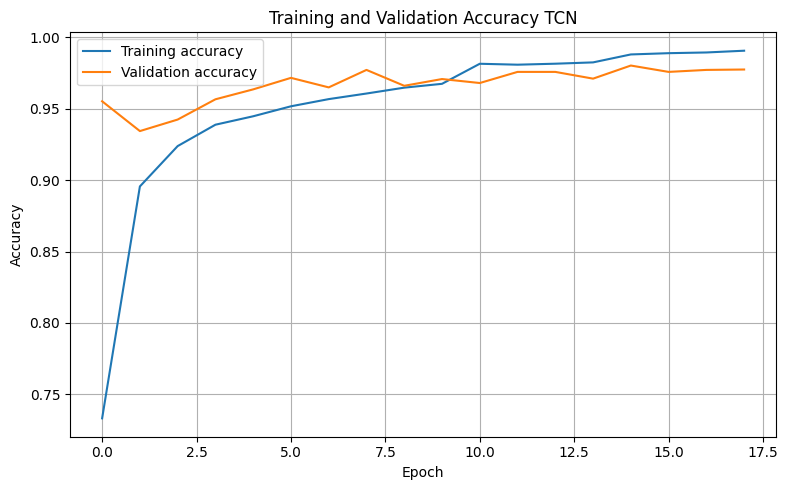

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Training and Validation Accuracy TCN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transformer_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

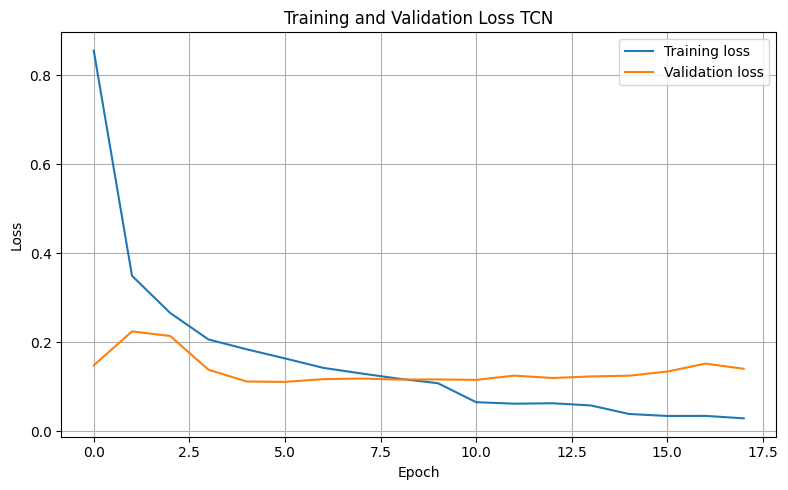

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Training and Validation Loss TCN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transformer_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()